# Live Demo - Trực quan hóa & Gợi ý mua hàng bằng Adamic-Adar

**Người thực hiện:** Phan Lê Trường An  
**Đề tài:** Phân tích mạng lưới mua sắm đồng thời trên Amazon và ứng dụng Link Prediction trong hệ thống gợi ý.

Notebook này chỉ dùng các file kết quả cuối cùng của nhóm:

- `amazon_graph.gpickle`: đồ thị Amazon co-purchasing sau tiền xử lý.
- `centrality_scores.csv`: điểm Degree, Betweenness, PageRank.
- `cluster_labels.csv`: nhãn cụm Louvain.
- Thuật toán gợi ý chính: **Adamic-Adar Index** vì AUC = **0.7923**, cao hơn Jaccard = **0.7897**.

Mục tiêu demo:
1. Kiểm tra dữ liệu đầu vào.
2. Vẽ network: màu node theo community, kích thước node theo PageRank.
3. Nhập `product_id` và trả về Top 5 sản phẩm gợi ý bằng Adamic-Adar.


In [1]:
import os
import pickle
import math
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Kết nối với Google Drive
from google.colab import drive
drive.mount('/content/drive')

GRAPH_PATH = '/content/drive/MyDrive/Colab Notebooks/Do-an-SNA/data/processed/amazon_graph.gpickle'
CENTRALITY_PATH = '/content/drive/MyDrive/Colab Notebooks/Do-an-SNA/data/processed/centrality_scores.csv'
CLUSTER_PATH = '/content/drive/MyDrive/Colab Notebooks/Do-an-SNA/data/processed/cluster_labels.csv'

NETWORK_OVERVIEW_PATH = '/content/drive/MyDrive/Colab Notebooks/Do-an-SNA/outputs/figures/network_overview.png'
DEMO_IMAGE_PATH = '/content/drive/MyDrive/Colab Notebooks/Do-an-SNA/outputs/figures/demo_recommendation_415888.png'
DEMO_CSV_PATH = '/content/drive/MyDrive/Colab Notebooks/Do-an-SNA/data/processed/demo_recommendations_product_415888.csv'

print("Đang load dữ liệu...")
with open(GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

centrality_df = pd.read_csv(CENTRALITY_PATH)
cluster_df = pd.read_csv(CLUSTER_PATH)

cluster_map = dict(zip(cluster_df["Node_ID"], cluster_df["Cluster_ID"]))
pagerank_map = dict(zip(centrality_df["Node_ID"], centrality_df["PageRank"]))
betweenness_map = dict(zip(centrality_df["Node_ID"], centrality_df["Betweenness"]))
degree_count_map = dict(G.degree())

print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"Centrality rows: {len(centrality_df):,}")
print(f"Cluster label rows: {len(cluster_df):,}")
print(f"Số cụm Louvain: {cluster_df['Cluster_ID'].nunique()}")

Mounted at /content/drive
Đang load dữ liệu...
Graph: 8,000 nodes, 19,903 edges
Centrality rows: 8,000
Cluster label rows: 8,000
Số cụm Louvain: 50


In [2]:
def validate_inputs(G, centrality_df, cluster_df):
    graph_nodes = set(G.nodes())
    centrality_nodes = set(centrality_df["Node_ID"])
    cluster_nodes = set(cluster_df["Node_ID"])

    summary = {
        "Số nodes": G.number_of_nodes(),
        "Số edges": G.number_of_edges(),
        "Đồ thị connected": nx.is_connected(G),
        "Centrality đủ nodes": graph_nodes == centrality_nodes,
        "Cluster đủ nodes": graph_nodes == cluster_nodes,
        "Tổng PageRank": round(centrality_df["PageRank"].sum(), 6),
        "Số cụm Louvain": cluster_df["Cluster_ID"].nunique()
    }

    return pd.DataFrame(list(summary.items()), columns=["Kiểm tra", "Kết quả"])

validate_inputs(G, centrality_df, cluster_df)

,Kiểm tra,Kết quả
0,Số nodes,8000
1,Số edges,19903
2,Đồ thị connected,True
3,Centrality đủ nodes,True
4,Cluster đủ nodes,True
5,Tổng PageRank,1.0
6,Số cụm Louvain,50


In [3]:
# Tính lại Modularity từ cluster_labels.csv để đưa vào báo cáo
communities = [set(group["Node_ID"]) for _, group in cluster_df.groupby("Cluster_ID")]
modularity = nx.algorithms.community.quality.modularity(G, communities)
print(f"Modularity = {modularity:.4f}")

Modularity = 0.8643


In [5]:
# Top sản phẩm quan trọng theo PageRank
top_pagerank = centrality_df.copy()
top_pagerank["Degree_Count"] = top_pagerank["Node_ID"].map(degree_count_map)
top_pagerank["Cluster_ID"] = top_pagerank["Node_ID"].map(cluster_map)
top_pagerank = top_pagerank.nlargest(10, "PageRank")

top_pagerank[["Node_ID", "Cluster_ID", "Degree_Count", "PageRank", "Degree", "Betweenness"]]

,Node_ID,Cluster_ID,Degree_Count,PageRank,Degree,Betweenness
6080,548091,24,549,0.016037,0.068634,0.695333
5609,415888,10,110,0.003290,0.013752,0.023181
5377,317053,10,149,0.002878,0.018627,0.026827
2884,537519,10,139,0.002876,0.017377,0.025412
2348,109200,2,82,0.002719,0.010251,0.018820
2534,208249,7,116,0.002450,0.014502,0.044905
3016,341570,10,106,0.002054,0.013252,0.015698
648,199628,10,103,0.001877,0.012877,0.004705
7860,32104,41,59,0.001716,0.007376,0.012620
7837,97579,3,83,0.001618,0.010376,0.015495


## 1. Trực quan hóa tổng quan mạng lưới

/tmp/ipykernel_3241/1157044770.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(unique_clusters), 1))


Đã lưu hình network overview tại: /content/drive/MyDrive/Colab Notebooks/Do-an-SNA/outputs/figures/network_overview.png


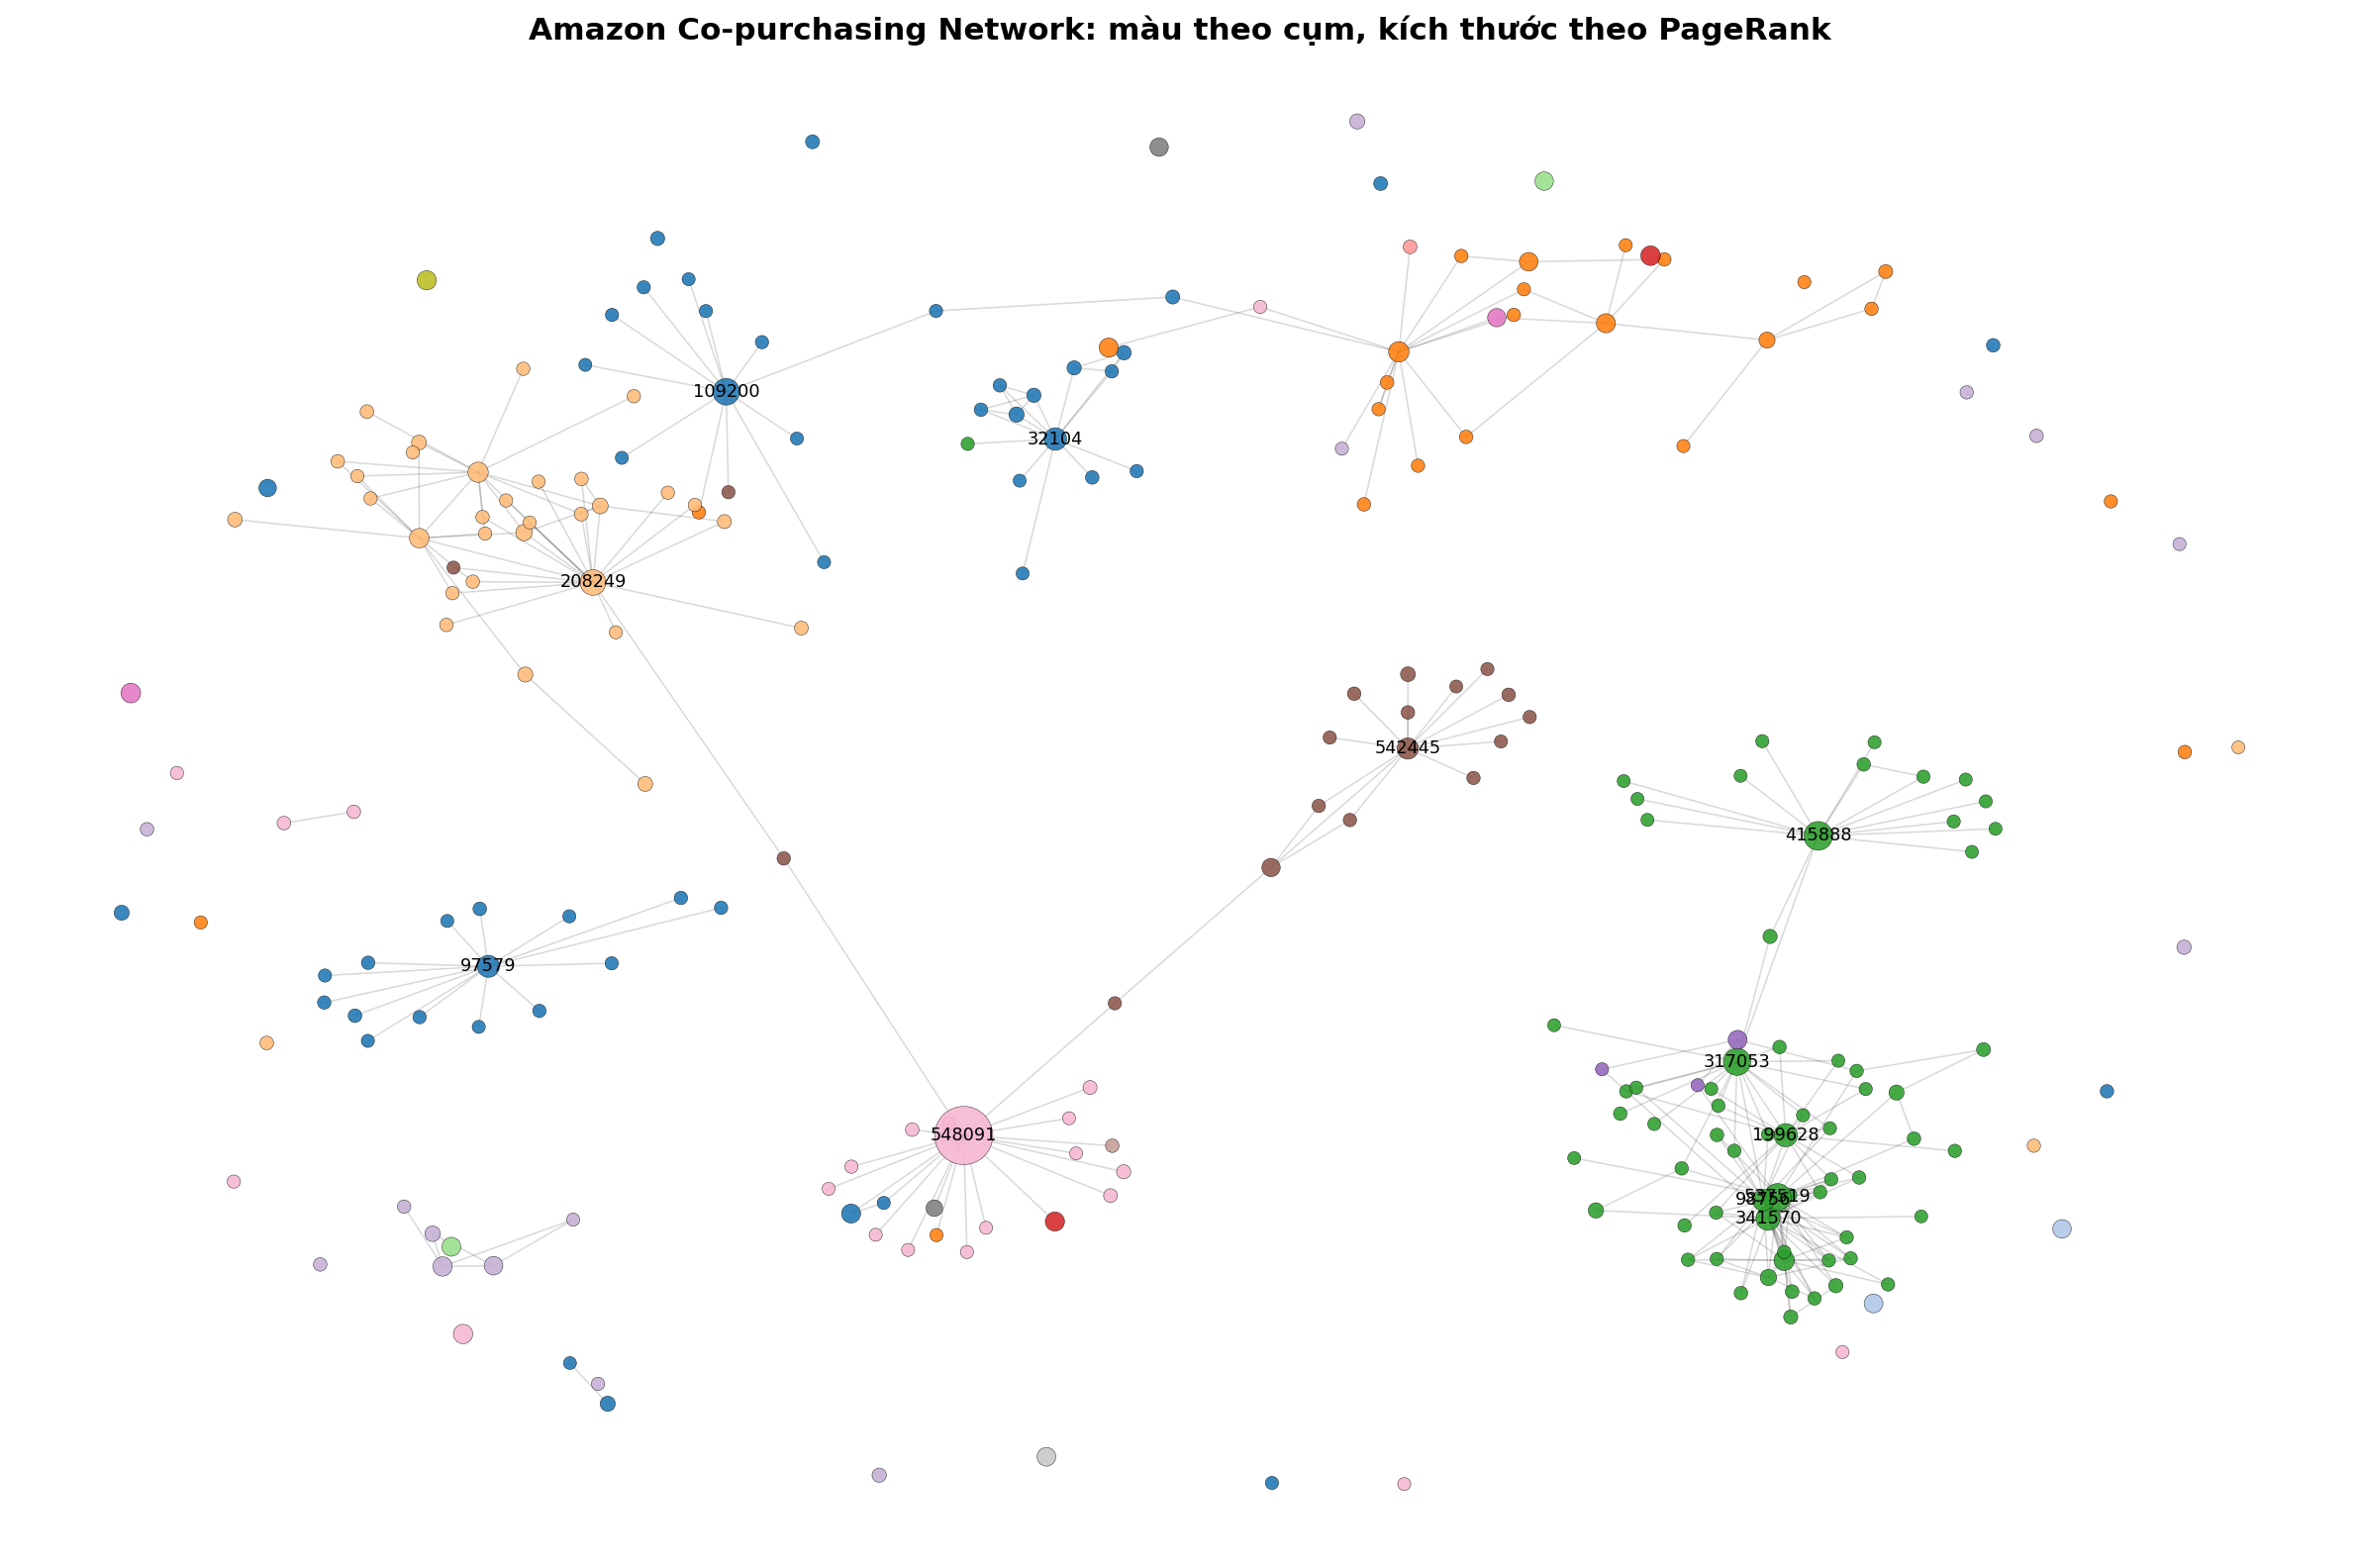

In [6]:
def node_sizes_for(nodes, min_size=40, max_size=700):
    values = np.array([pagerank_map.get(int(n), 0) for n in nodes], dtype=float)
    if values.max() == values.min():
        return np.full(len(nodes), (min_size + max_size) / 2)
    return min_size + (values - values.min()) / (values.max() - values.min()) * (max_size - min_size)

def draw_network_overview(output_path=NETWORK_OVERVIEW_PATH):
    # Lấy các node PageRank cao + một phần hàng xóm để đồ thị không quá rối
    top_nodes = list(centrality_df.nlargest(35, "PageRank")["Node_ID"].astype(int))
    selected = set(top_nodes)

    for node in top_nodes[:15]:
        selected.update(list(G.neighbors(node))[:12])

    # Bổ sung một ít node từ các cụm lớn để thể hiện community
    for cluster_id in cluster_df["Cluster_ID"].value_counts().head(6).index:
        cluster_nodes = cluster_df[cluster_df["Cluster_ID"] == cluster_id]["Node_ID"].astype(int).tolist()
        selected.update(cluster_nodes[:12])

    if len(selected) > 320:
        selected = sorted(selected, key=lambda x: pagerank_map.get(x, 0), reverse=True)[:320]

    H = G.subgraph(selected).copy()

    plt.figure(figsize=(15, 10), dpi=160)
    pos = nx.spring_layout(H, seed=42, k=0.22, iterations=80)

    cluster_values = [cluster_map.get(int(n), -1) for n in H.nodes()]
    unique_clusters = sorted(set(cluster_values))
    cmap = plt.cm.get_cmap("tab20", max(len(unique_clusters), 1))
    color_lookup = {c: cmap(i % 20) for i, c in enumerate(unique_clusters)}
    colors = [color_lookup[c] for c in cluster_values]

    nx.draw_networkx_edges(H, pos, alpha=0.15, width=0.7)
    nx.draw_networkx_nodes(
        H, pos,
        node_color=colors,
        node_size=node_sizes_for(list(H.nodes()), 35, 700),
        alpha=0.88,
        linewidths=0.2,
        edgecolors="black"
    )

    label_nodes = list(
        centrality_df[centrality_df["Node_ID"].isin(H.nodes())]
        .nlargest(12, "PageRank")["Node_ID"]
        .astype(int)
    )
    labels = {n: str(n) for n in label_nodes}
    nx.draw_networkx_labels(H, pos, labels=labels, font_size=8)

    plt.title("Amazon Co-purchasing Network: màu theo cụm, kích thước theo PageRank", fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight")
    print(f"Đã lưu hình network overview tại: {output_path}")
    plt.show()

draw_network_overview()

## 2. Hàm gợi ý sản phẩm bằng Adamic-Adar

In [7]:
def recommend_adamic_adar(product_id, top_n=5):
    """
    Gợi ý sản phẩm bằng Adamic-Adar Index.

    Ý tưởng:
    - Chỉ xét các sản phẩm chưa được nối trực tiếp với product_id.
    - Điểm càng cao khi hai sản phẩm có nhiều hàng xóm chung.
    - Hàng xóm chung có degree thấp sẽ có trọng số cao hơn, giúp gợi ý đặc thù hơn Jaccard.
    """
    product_id = int(product_id)

    if product_id not in G:
        raise ValueError(f"Product ID {product_id} không tồn tại trong graph.")

    neighbors = set(G.neighbors(product_id))
    scores = {}

    for common_neighbor in neighbors:
        degree_common = G.degree(common_neighbor)
        if degree_common <= 1:
            continue

        weight = 1.0 / math.log(degree_common)

        for candidate in G.neighbors(common_neighbor):
            if candidate == product_id or candidate in neighbors:
                continue
            scores[candidate] = scores.get(candidate, 0.0) + weight

    ranked = sorted(
        scores.items(),
        key=lambda item: (item[1], pagerank_map.get(item[0], 0)),
        reverse=True
    )[:top_n]

    result = []
    for rank, (node_id, score) in enumerate(ranked, start=1):
        result.append({
            "Rank": rank,
            "Recommended_Node_ID": int(node_id),
            "Adamic_Adar_Score": round(float(score), 4),
            "Cluster_ID": int(cluster_map.get(node_id, -1)),
            "PageRank": round(float(pagerank_map.get(node_id, 0)), 6),
            "Degree_Count": int(degree_count_map.get(node_id, 0))
        })

    return pd.DataFrame(result)

# Demo nhanh với một sản phẩm PageRank cao nhưng không quá nhiều cạnh
recommend_adamic_adar(415888, top_n=5)

,Rank,Recommended_Node_ID,Adamic_Adar_Score,Cluster_ID,PageRank,Degree_Count
0,1,532098,7.0135,10,0.000199,7
1,2,390503,5.8385,10,0.000250,12
2,3,337345,5.2283,10,0.000255,10
3,4,537111,4.7757,10,0.000231,11
4,5,122108,4.1206,10,0.000185,7


## 3. Live Demo

DEMO GỢI Ý MUA HÀNG CHO PRODUCT ID: 415888
Cụm ngành hàng / Community ID: 10
Degree Count: 110
PageRank: 0.003290

Top sản phẩm gợi ý:


,Rank,Recommended_Node_ID,Adamic_Adar_Score,Cluster_ID,PageRank,Degree_Count
0,1,532098,7.0135,10,0.000199,7
1,2,390503,5.8385,10,0.000250,12
2,3,337345,5.2283,10,0.000255,10
3,4,537111,4.7757,10,0.000231,11
4,5,122108,4.1206,10,0.000185,7


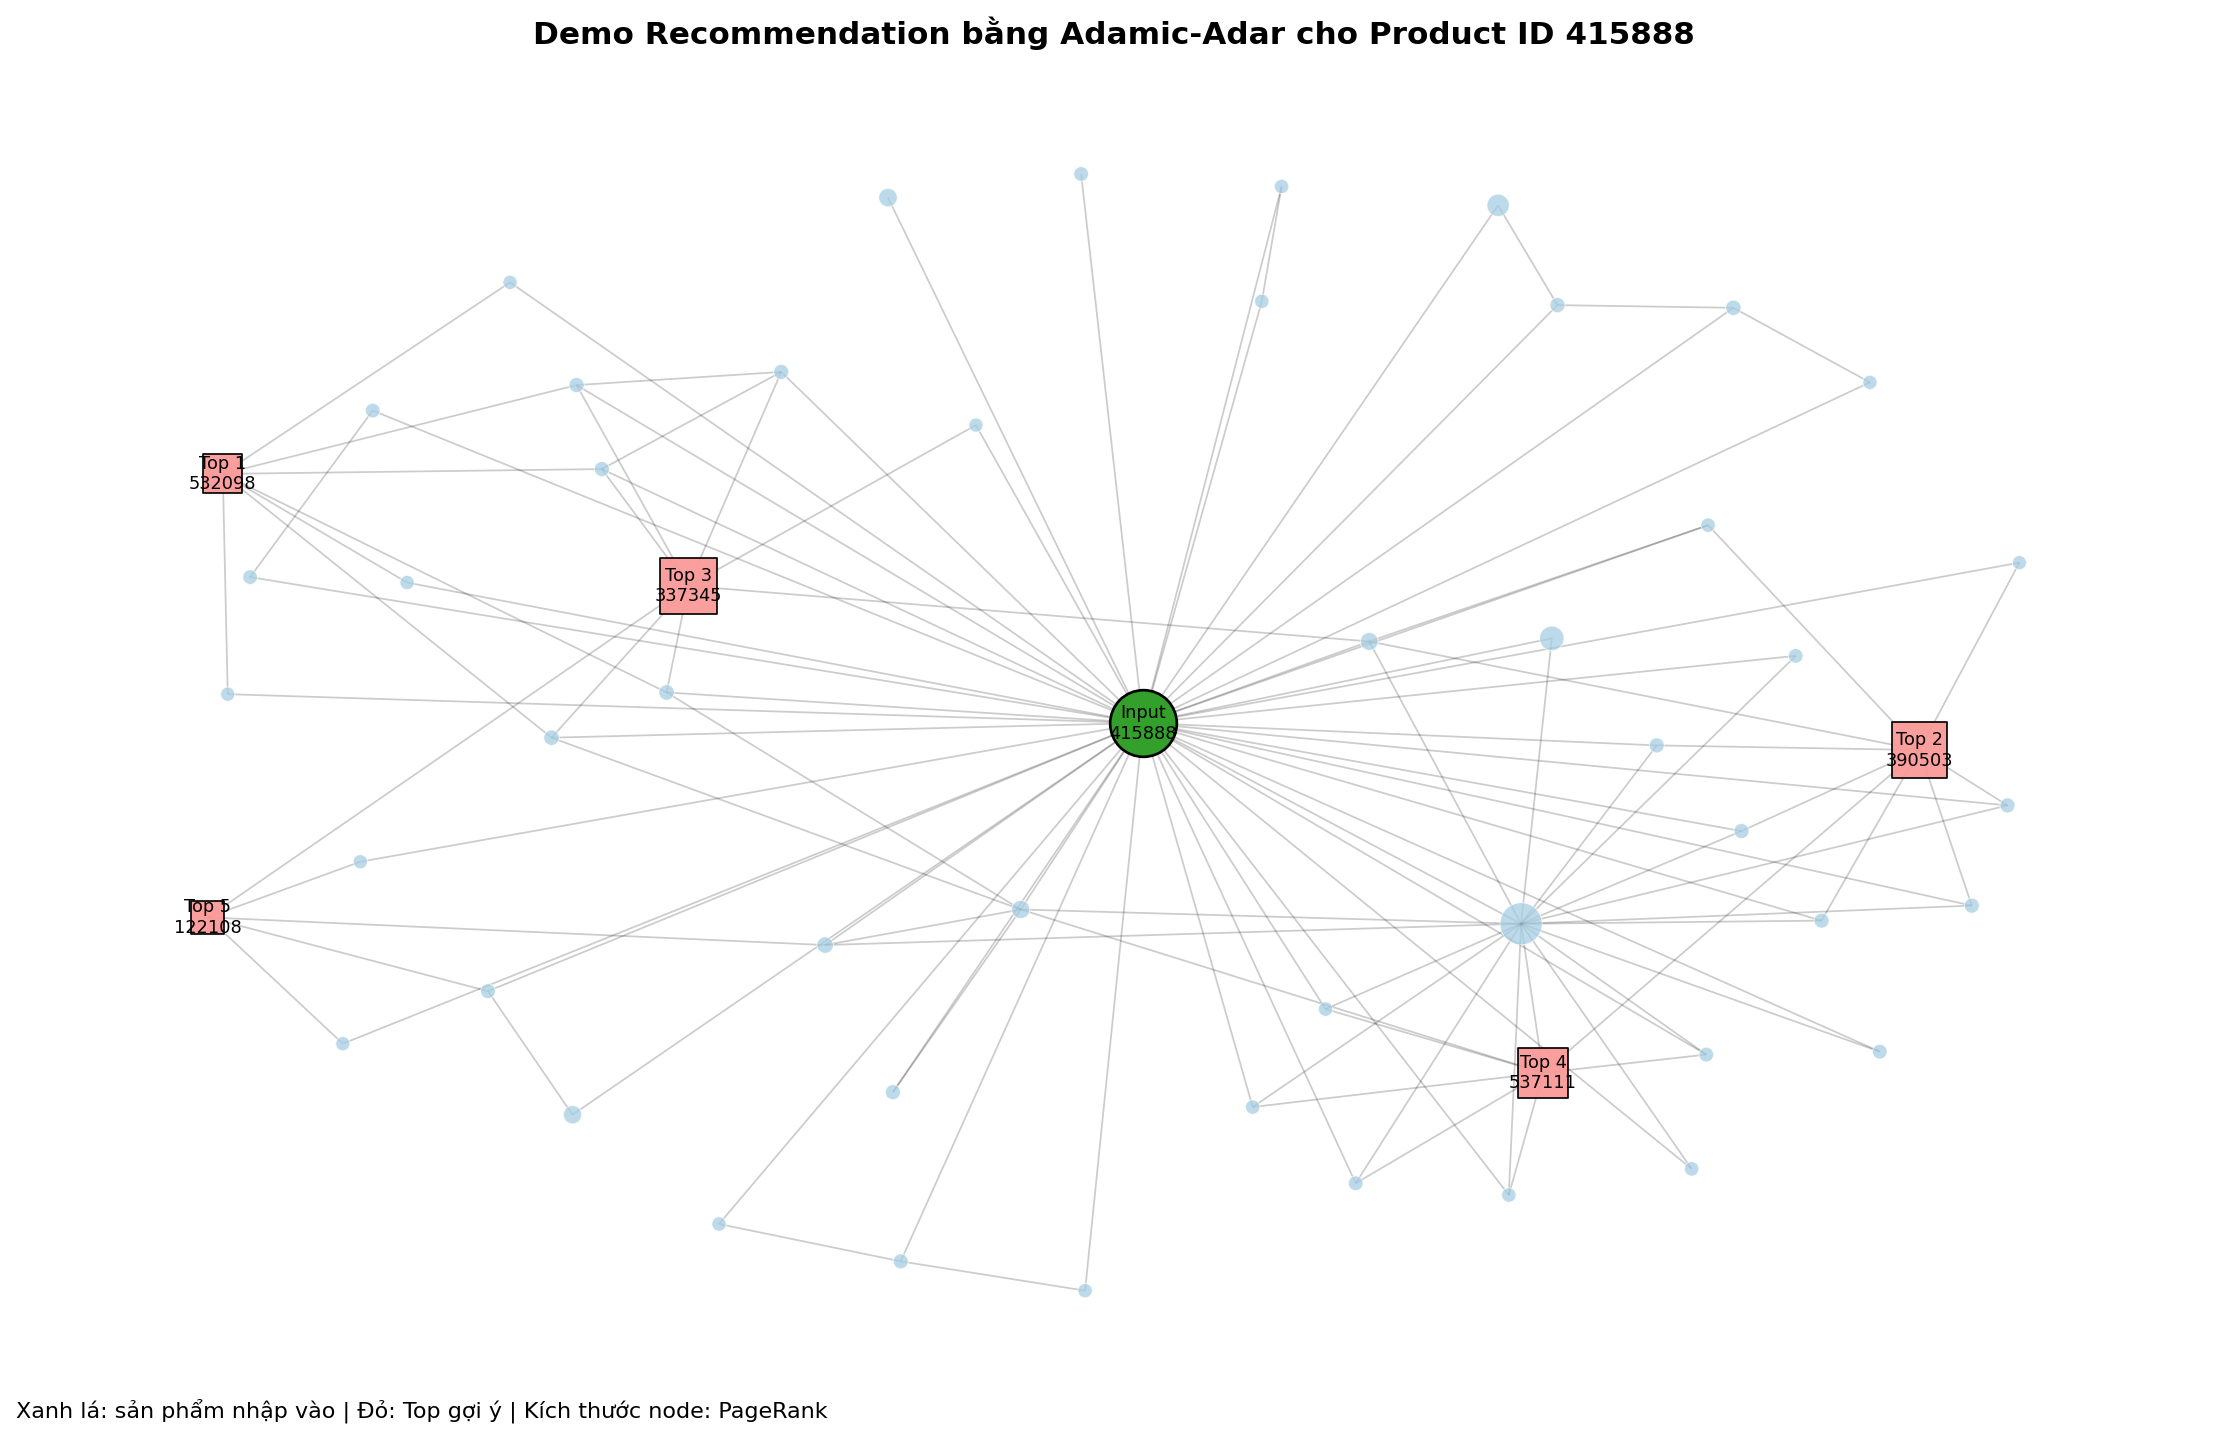

Đã lưu hình demo: /content/drive/MyDrive/Colab Notebooks/Do-an-SNA/outputs/figures/demo_recommendation_415888.png
Đã lưu file gợi ý: /content/drive/MyDrive/Colab Notebooks/Do-an-SNA/data/processed/demo_recommendations_product_415888.csv


In [16]:
def demo_recommendation(product_id, top_n=5, output_path=None, csv_path=None):
    # Kiểm tra input cơ bản
    try:
        product_id = int(str(product_id).strip())
    except ValueError:
        print("Product ID phải là số nguyên. Ví dụ: 415888")
        return pd.DataFrame(columns=RECOMMENDATION_COLUMNS)

    if product_id not in G:
        print(f"Product ID {product_id} không tồn tại trong graph.")
        print("Bạn có thể thử một vài Product ID mẫu sau:")
        sample_nodes = list(centrality_df.nlargest(10, "PageRank")["Node_ID"].astype(int))
        print(sample_nodes)
        return pd.DataFrame(columns=RECOMMENDATION_COLUMNS)

    rec_df = recommend_adamic_adar(product_id, top_n)

    used_fallback = False
    if rec_df.empty:
        used_fallback = True
        print("Không tìm thấy ứng viên Adamic-Adar phù hợp. Chuyển sang gợi ý cùng community theo PageRank.")
        rec_df = fallback_recommend_same_cluster(product_id, top_n)

    print("=" * 70)
    print(f"DEMO GỢI Ý MUA HÀNG CHO PRODUCT ID: {product_id}")
    print("=" * 70)
    print(f"Cụm ngành hàng / Community ID: {cluster_map.get(product_id, 'N/A')}")
    print(f"Degree Count: {degree_count_map.get(product_id, 0)}")
    print(f"PageRank: {pagerank_map.get(product_id, 0):.6f}")
    print("\nTop sản phẩm gợi ý:")
    display(rec_df)

    if rec_df.empty:
        print("Không có sản phẩm gợi ý để vẽ network.")
        return rec_df

    recommendation_nodes = set(rec_df["Recommended_Node_ID"].astype(int).tolist())
    neighbors = sorted(
        list(G.neighbors(product_id)),
        key=lambda x: pagerank_map.get(x, 0),
        reverse=True
    )[:40]

    selected_nodes = set(neighbors) | recommendation_nodes | {product_id}

    for rec_node in recommendation_nodes:
        common_neighbors = set(G.neighbors(product_id)).intersection(set(G.neighbors(rec_node)))
        selected_nodes.update(list(common_neighbors)[:12])

    H = G.subgraph(selected_nodes).copy()

    plt.figure(figsize=(14, 9), dpi=160)
    pos = nx.spring_layout(H, seed=7, k=0.25, iterations=90)

    normal_nodes = [n for n in H.nodes() if n != product_id and n not in recommendation_nodes]
    rec_nodes = [n for n in H.nodes() if n in recommendation_nodes]

    nx.draw_networkx_edges(H, pos, alpha=0.2, width=0.8)
    nx.draw_networkx_nodes(
        H, pos,
        nodelist=normal_nodes,
        node_color="#A6CEE3",
        node_size=node_sizes_for(normal_nodes, 40, 360),
        alpha=0.75,
        edgecolors="white",
        linewidths=0.4
    )
    nx.draw_networkx_nodes(
        H, pos,
        nodelist=rec_nodes,
        node_color="#FB9A99",
        node_shape="s",
        node_size=node_sizes_for(rec_nodes, 220, 650),
        alpha=0.95,
        edgecolors="black",
        linewidths=0.8
    )
    nx.draw_networkx_nodes(
        H, pos,
        nodelist=[product_id],
        node_color="#33A02C",
        node_size=900,
        alpha=1,
        edgecolors="black",
        linewidths=1.2
    )

    labels = {product_id: f"Input\n{product_id}"}
    labels.update({
        int(row.Recommended_Node_ID): f"Top {int(row.Rank)}\n{int(row.Recommended_Node_ID)}"
        for row in rec_df.itertuples()
    })
    nx.draw_networkx_labels(H, pos, labels=labels, font_size=8)

    method_name = "Same Community + PageRank" if used_fallback else "Adamic-Adar"
    plt.title(f"Demo Recommendation bằng {method_name} cho Product ID {product_id}", fontsize=14, fontweight="bold")
    plt.figtext(0.01, 0.01, "Xanh lá: sản phẩm nhập vào | Đỏ: Top gợi ý | Kích thước node: PageRank", fontsize=10)
    plt.axis("off")
    plt.tight_layout()

    if output_path is None:
        output_path = f"/content/drive/MyDrive/Colab Notebooks/Do-an-SNA/outputs/figures/demo_recommendation_{product_id}.png"

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, bbox_inches="tight")
    plt.show()
    print(f"Đã lưu hình demo: {output_path}")

    if csv_path is None:
        csv_path = f"/content/drive/MyDrive/Colab Notebooks/Do-an-SNA/data/processed/demo_recommendations_product_{product_id}.csv"

    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    rec_df.to_csv(csv_path, index=False)
    print(f"Đã lưu file gợi ý: {csv_path}")

    return rec_df

# Demo mặc định
rec_df = demo_recommendation(415888, top_n=5)



Nhập Product ID: 65536
DEMO GỢI Ý MUA HÀNG CHO PRODUCT ID: 65536
Cụm ngành hàng / Community ID: 0
Degree Count: 2
PageRank: 0.000077

Top sản phẩm gợi ý:


,Rank,Recommended_Node_ID,Adamic_Adar_Score,Cluster_ID,PageRank,Degree_Count
0,1,548091,1.4427,24,0.016037,549
1,2,31355,0.5581,48,0.000435,17
2,3,19542,0.5581,0,0.000249,9
3,4,95718,0.5581,0,0.000171,6
4,5,480493,0.5581,0,0.000095,3


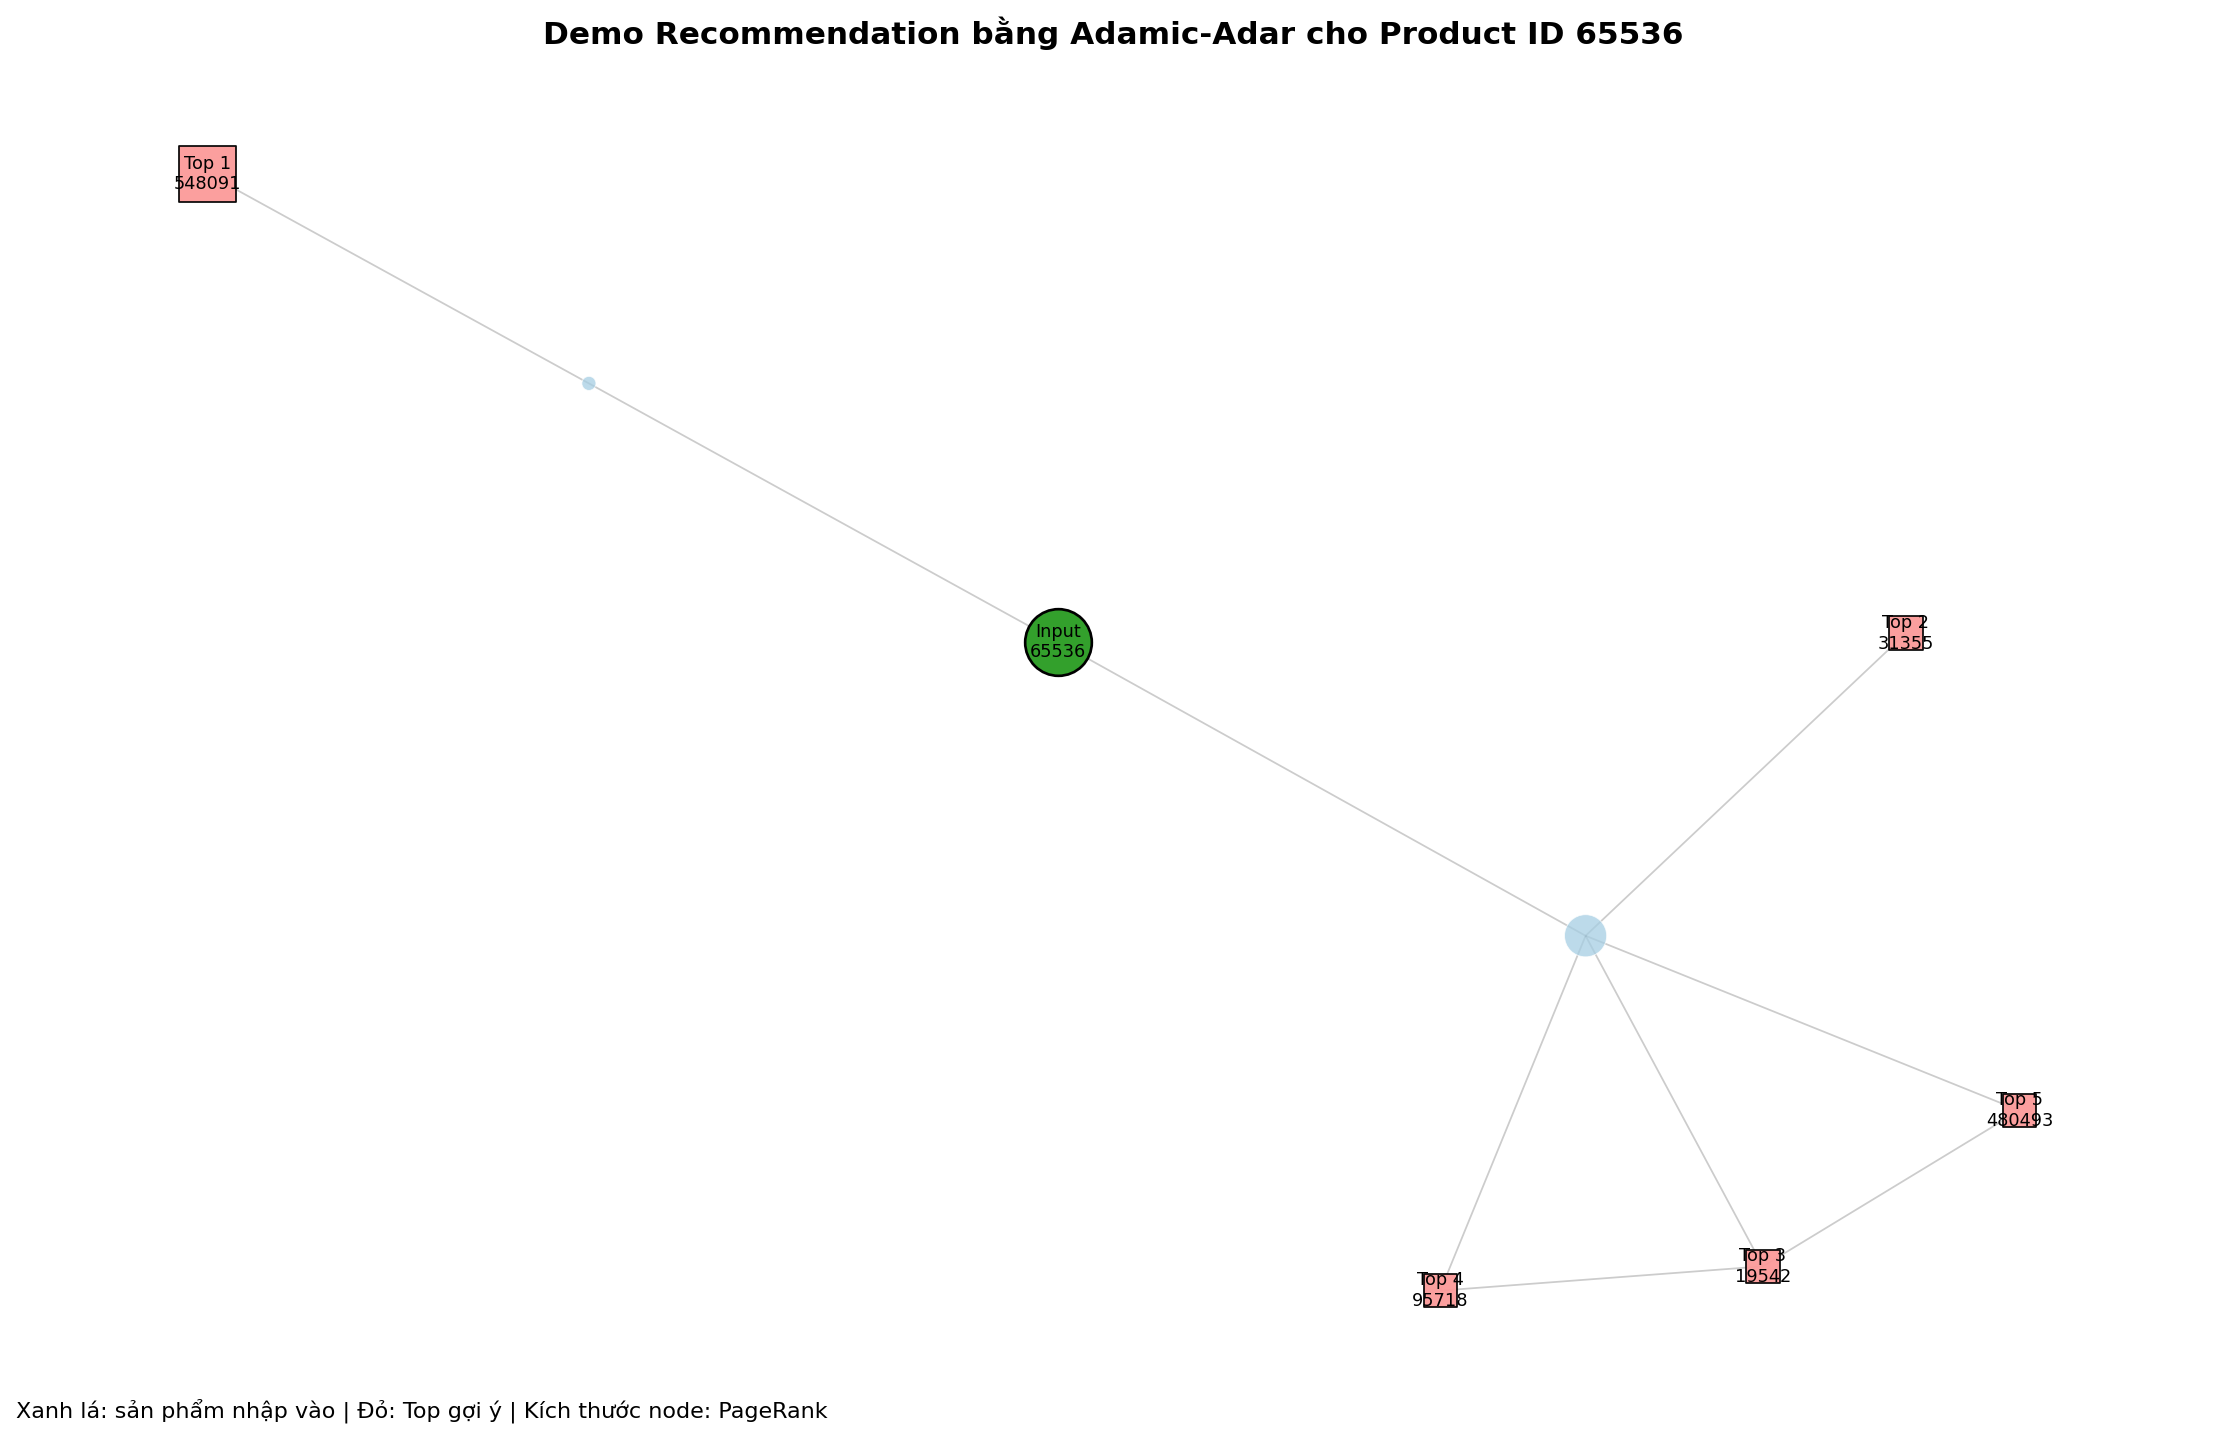

Đã lưu hình demo: /content/drive/MyDrive/Colab Notebooks/Do-an-SNA/outputs/figures/demo_recommendation_65536.png
Đã lưu file gợi ý: /content/drive/MyDrive/Colab Notebooks/Do-an-SNA/data/processed/demo_recommendations_product_65536.csv


In [17]:
# Cell cho người dùng nhập Product ID bất kỳ
user_input = input("Nhập Product ID: ")
rec_df = demo_recommendation(user_input, top_n=5)